Mounted at /content/drive
📂 Loading processed data from Drive...
✅ Loaded successfully | Shape: (229743, 11)

📈 Running forecasts...
➡️ Forecasting US
➡️ Forecasting India
➡️ Forecasting Brazil
➡️ Forecasting France
➡️ Forecasting Germany

✅ Models saved: ['US', 'India', 'Brazil', 'France', 'Germany']


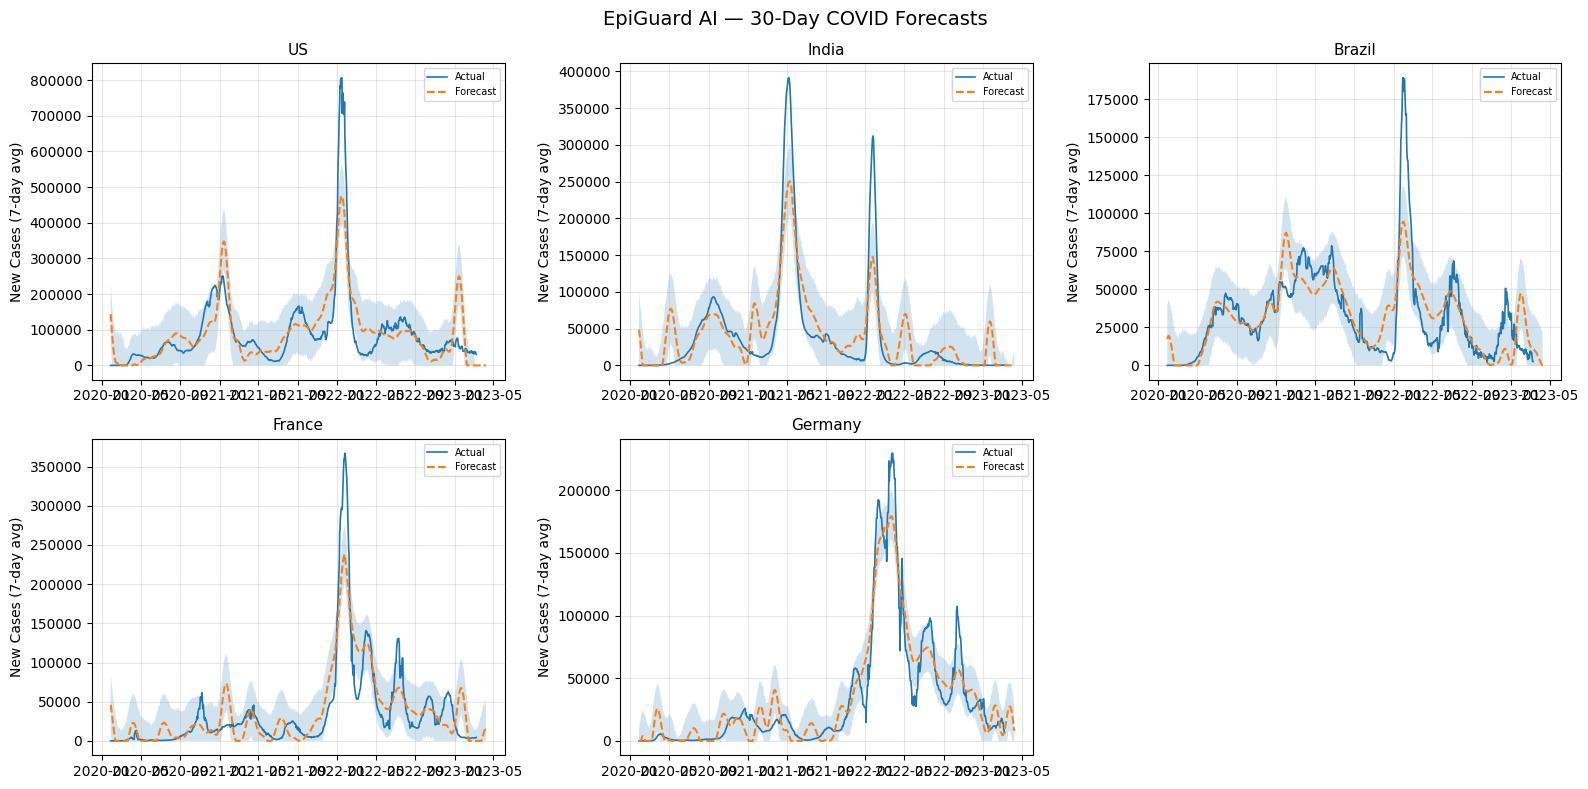

✅ Forecast plot saved to Drive

🤖 Running XGBoost baseline...
✅ XGBoost → MAE: 2467 | RMSE: 3511
✅ Forecast results saved to Google Drive

── Model Comparison Summary ──
Prophet  → Multi-country probabilistic forecasting
XGBoost  → US baseline | MAE: 2467 | RMSE: 3511

🎯 Notebook 2 completed successfully.


In [7]:
# ============================================================
# EpiGuard AI — Notebook 2: Forecasting with Prophet + XGBoost
# ============================================================

# ── 0. GOOGLE DRIVE SETUP ────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
import warnings
warnings.filterwarnings('ignore')

BASE_PATH = "/content/drive/MyDrive/EpiGuard_AI"
PROCESSED_PATH = f"{BASE_PATH}/data/processed"
MODEL_PATH = f"{BASE_PATH}/models"

os.makedirs(PROCESSED_PATH, exist_ok=True)
os.makedirs(MODEL_PATH, exist_ok=True)

# ── 1. INSTALL + IMPORT LIBRARIES ────────────────────────────
try:
    from prophet import Prophet
except:
    !pip install prophet -q
    from prophet import Prophet

try:
    from xgboost import XGBRegressor
except:
    !pip install xgboost -q
    from xgboost import XGBRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error

# ── 2. LOAD PROCESSED DATA ───────────────────────────────────
print("📂 Loading processed data from Drive...")
df = pd.read_csv(
    f"{PROCESSED_PATH}/processed_covid.csv",
    parse_dates=['date']
)
print(f"✅ Loaded successfully | Shape: {df.shape}")

# ── 3. FORECAST FUNCTION (PROPHET) ───────────────────────────
def forecast_country(df, country, periods=30):
    d = df[df['Country/Region'] == country][['date', 'rolling_7']].dropna()
    d.columns = ['ds', 'y']
    d = d[d['y'] >= 0].copy()

    if len(d) < 60:
        print(f"⚠️ Not enough data for {country}")
        return None, None

    model = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=True,
        daily_seasonality=False,
        changepoint_prior_scale=0.1,
        seasonality_prior_scale=10
    )

    model.fit(d)

    future = model.make_future_dataframe(periods=periods)
    forecast = model.predict(future)

    # prevent negative case predictions
    forecast[['yhat', 'yhat_lower', 'yhat_upper']] = \
        forecast[['yhat', 'yhat_lower', 'yhat_upper']].clip(lower=0)

    return model, forecast

# ── 4. RUN MULTI-COUNTRY FORECASTS ───────────────────────────
countries_to_forecast = ['US', 'India', 'Brazil', 'France', 'Germany']
all_forecasts = {}

print("\n📈 Running forecasts...")
for country in countries_to_forecast:
    print(f"➡️ Forecasting {country}")
    model, forecast = forecast_country(df, country, periods=30)

    if forecast is not None:
        all_forecasts[country] = forecast

        # save Prophet model
        with open(f"{MODEL_PATH}/model_{country.replace(' ', '_')}.pkl", "wb") as f:
            pickle.dump(model, f)

print(f"\n✅ Models saved: {list(all_forecasts.keys())}")

# ── 5. PLOT FORECASTS ────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, (country, forecast) in enumerate(all_forecasts.items()):
    ax = axes[i]

    d = df[df['Country/Region'] == country][['date', 'rolling_7']].dropna()
    d.columns = ['ds', 'y']

    ax.plot(d['ds'], d['y'], linewidth=1.2, label='Actual')
    ax.plot(forecast['ds'], forecast['yhat'], linestyle='--', linewidth=1.5, label='Forecast')
    ax.fill_between(
        forecast['ds'],
        forecast['yhat_lower'],
        forecast['yhat_upper'],
        alpha=0.2
    )

    ax.set_title(country, fontsize=11)
    ax.set_ylabel("New Cases (7-day avg)")
    ax.legend(fontsize=7)
    ax.grid(alpha=0.3)

axes[-1].axis('off')
plt.suptitle("EpiGuard AI — 30-Day COVID Forecasts", fontsize=14)
plt.tight_layout()
plt.savefig(f"{PROCESSED_PATH}/forecast_all_countries.png", dpi=150)
plt.show()

print("✅ Forecast plot saved to Drive")

# ── 6. XGBOOST BASELINE (US) ─────────────────────────────────
def make_lag_features(series, lags=14):
    lag_df = pd.DataFrame({'y': series.values})

    for lag in range(1, lags + 1):
        lag_df[f'lag_{lag}'] = lag_df['y'].shift(lag)

    lag_df['rolling_3'] = lag_df['y'].shift(1).rolling(3).mean()
    lag_df['rolling_7'] = lag_df['y'].shift(1).rolling(7).mean()
    lag_df['rolling_14'] = lag_df['y'].shift(1).rolling(14).mean()

    return lag_df.dropna()

print("\n🤖 Running XGBoost baseline...")
us_data = df[df['Country/Region'] == 'US'][['rolling_7']].dropna()
lag_df = make_lag_features(us_data['rolling_7'])

X = lag_df.drop(columns='y')
y = lag_df['y']

split = int(len(X) * 0.8)
X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

xgb = XGBRegressor(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    objective='reg:squarederror'
)

xgb.fit(X_train, y_train)
preds = xgb.predict(X_test)

mae = mean_absolute_error(y_test, preds)
rmse = np.sqrt(mean_squared_error(y_test, preds))

print(f"✅ XGBoost → MAE: {mae:.0f} | RMSE: {rmse:.0f}")

# save XGBoost model
with open(f"{MODEL_PATH}/xgb_us_baseline.pkl", "wb") as f:
    pickle.dump(xgb, f)

# ── 7. EXPORT FORECAST RESULTS + ALERTS ──────────────────────
results = []

for country, forecast in all_forecasts.items():
    last30 = forecast.tail(30)[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].copy()
    last30['country'] = country

    # outbreak surge alert logic
    last30['alert'] = np.where(
        last30['yhat'] > last30['yhat'].mean() * 1.5,
        'Potential Surge',
        'Stable'
    )

    results.append(last30)

forecast_df = pd.concat(results, ignore_index=True)

forecast_df.to_csv(
    f"{PROCESSED_PATH}/forecast_results.csv",
    index=False
)

print("✅ Forecast results saved to Google Drive")

# ── 8. MODEL SUMMARY ─────────────────────────────────────────
print("\n── Model Comparison Summary ──")
print("Prophet  → Multi-country probabilistic forecasting")
print(f"XGBoost  → US baseline | MAE: {mae:.0f} | RMSE: {rmse:.0f}")
print("\n🎯 Notebook 2 completed successfully.")